In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project = 'analog-foundry-466522-c7')

## Machine Learning Models

While most of the mll algorhthms available in SKLEARN(and several other compatible libraries, such as LightGbM) are commonly used for regression and tabular classification, there is no inherent reason why they cannot be effectively applied to time series forecasting.

From a theoretical perspective, these approaches may not necessarily satisfy the conditions required for a regression model. Time series data typically exhibit some degree of autocorrelation, meaning that data observed at time t is related to previous data (t-1) and possibly even more. A typical regression model typically assumes independent observations, so they mmay not be well suited to capture autocorrelation. However, it is still possible to use lagged series as predictors and allow the model to learn from existing autocorrelation or other patterns.

Sklearn offers a wide range of regression models, ranging from basic linear regression to highly advanced boosted trees. Along with this, hyperparameter tuning and implementing cross-validation are common practices to ensure better model generality and accuracy.

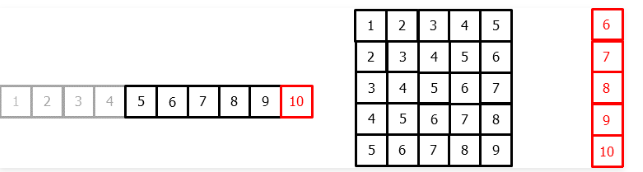

Since we are treating time series forecasting as a regression problem, we would need to have a predictor. Here, we assume that we only have a univariate series with 5 days

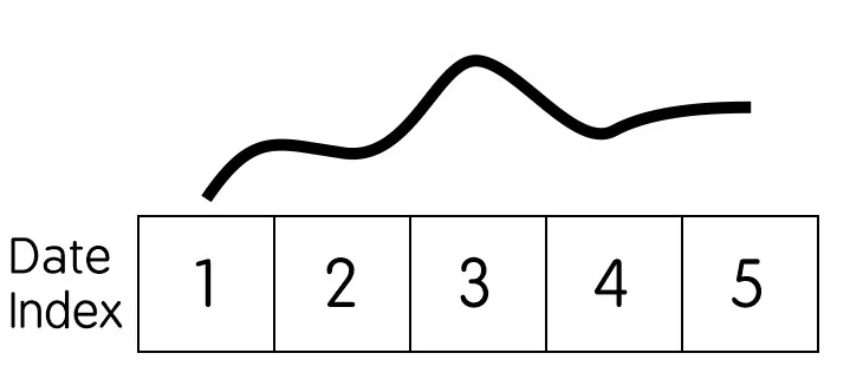



At the beginning, we only have data up to day 5. Let’s say we use the previous 3 days as the predictor. This means we are using up to 3 lagged data. To predict day 4, we use data from days 1 to 3. To predict day 5, we use data from days 2 to 4. Then, to predict day 6, we use data from days 3 to 5.

In tabular terms, we can write the predictor and the response as follows. We label yesterday’s data as Xt-1, two days ago as Xt-2, and three days ago as Xt-3.

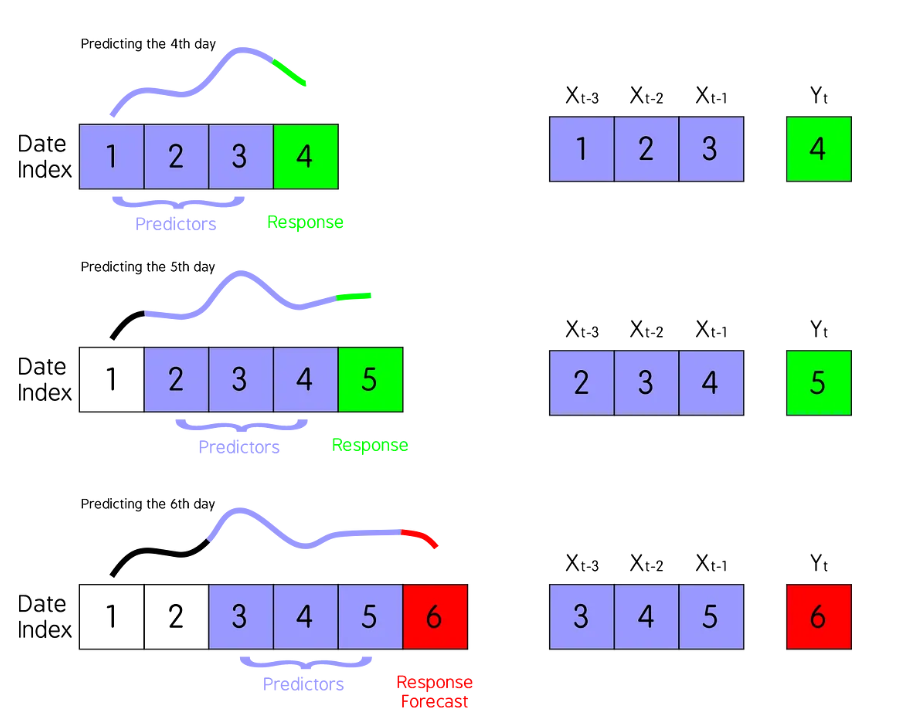

We have established a way to predict one step into the future. How about predicting 2 days ahead? Or 3? This is where we introduce the concept of recursive prediction. In short, to predict day 7, we make a prediction for day 6 and then use that predicted value as our Xt-1. Essentially, we are treating the previous prediction as a new predictor for the future. We do this as often as necessary and it is quite efficient.


image.png


However, there are several problems with this approach. If we want to predict far into the future, the model may give a relatively flat prediction. It may also introduce new bias, as the 6th predicted data may be far from the actual value.

Again, it is possible to include exogenous variables in the model. Keep in mind that to predict the 6th data, we must also provide the exogenous variable for that same index.

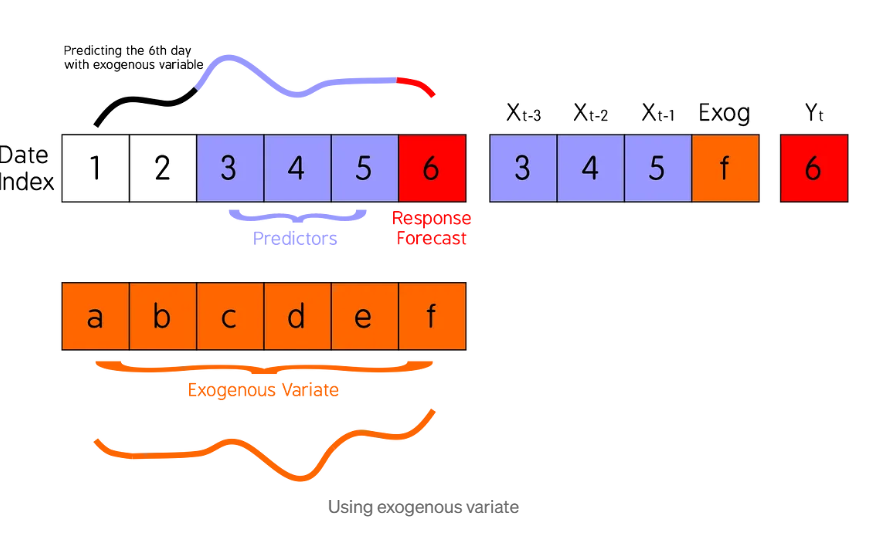

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import datetime

In [ ]:
italy = italy = ee.Geometry.Polygon([[[8.290016551188252, 45.79137351065613],
          [8.290016551188252, 45.0588767633071],
          [10.168678660563252, 45.0588767633071],
          [10.168678660563252, 45.79137351065613]]])